In [2]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np

Matplotlib is building the font cache; this may take a moment.


In [3]:
file_path = "/Users/jatinmishra/Desktop/Projects/ai-agents/BuildingModels/data/Iris Dataset/iris.data"

In [30]:
iris = pd.read_csv(file_path, header=None)
iris.columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "species"
]
# classification problem

In [9]:
iris[0:3]

,0,1,2,3,4
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa


In [10]:
iris.shape

(150, 5)

In [ ]:
iris[4].value_counts()
# balanced dataset vs imbalanced dataset

4
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

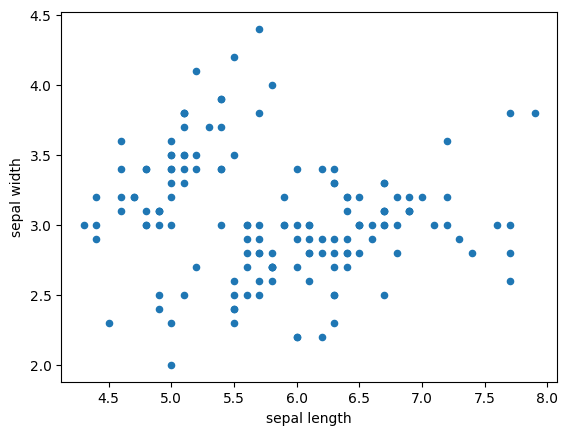

In [20]:
sl = 0
sw = 1
pl = 2
pw = 3
iris.plot(kind="scatter", x=sl, y=sw, xlabel="sepal length", ylabel="sepal width")
plt.show()

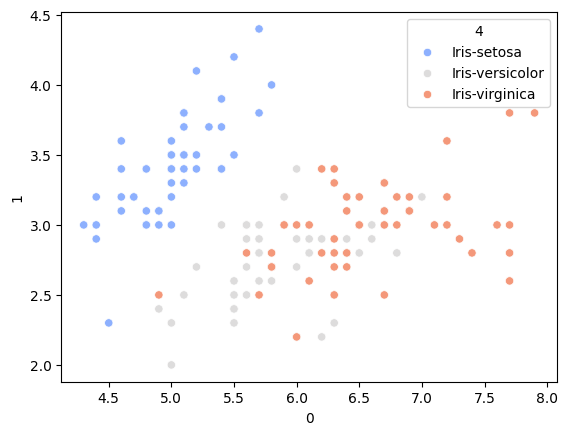

In [21]:

sns.scatterplot(
    data=iris,
    x=iris.columns[sl],      # sepal length
    y=iris.columns[sw],      # sepal width
    hue=iris.columns[4],    # fourth feature (continuous → color gradient)
    palette="coolwarm"
)
plt.show()

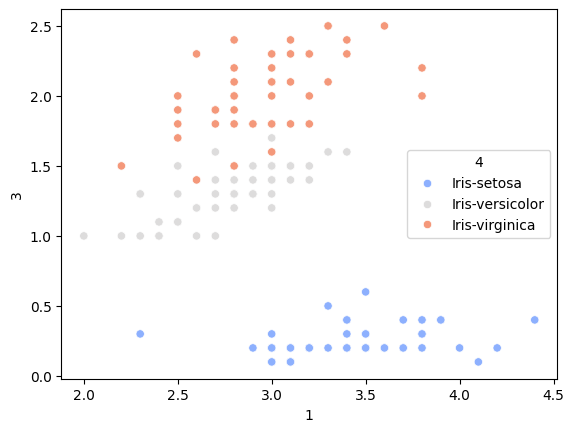

In [27]:

sns.scatterplot(
    data=iris,
    x=iris.columns[sw],      # sepal length
    y=iris.columns[pw],      # sepal width
    hue=iris.columns[4],    # fourth feature (continuous → color gradient)
    palette="coolwarm"
)
plt.show()

In [28]:
# 3D scatter plot -> plotly 

# Pair Plot

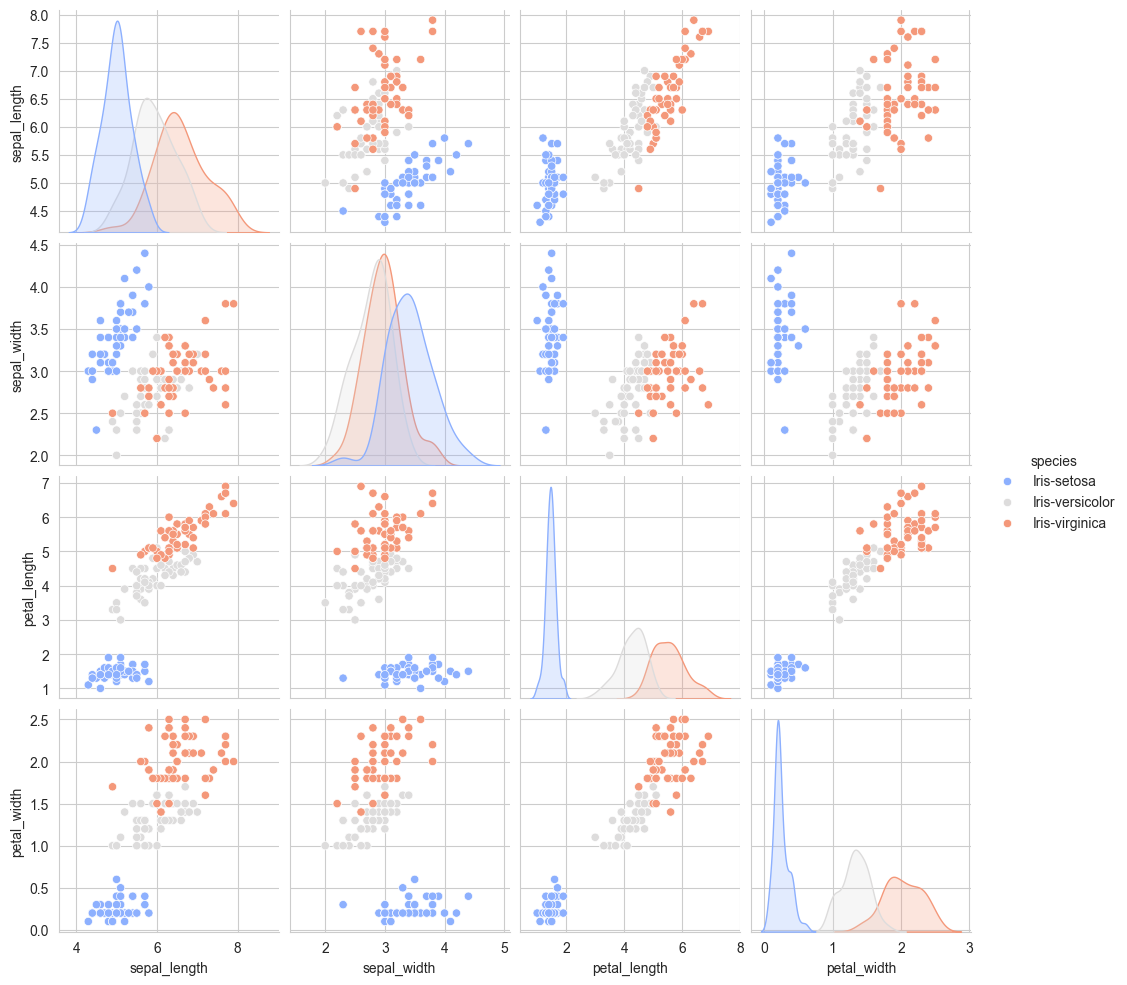

In [33]:
plt.close()
sns.set_style("whitegrid")
sns.pairplot(iris, hue="species", palette="coolwarm")
plt.show()
# Good when we have a small number of features (2-4) and want to see all pairwise relationships. Can be overwhelming with more features.

# 1-D scatter plot

In [39]:
iris[0:3]
features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

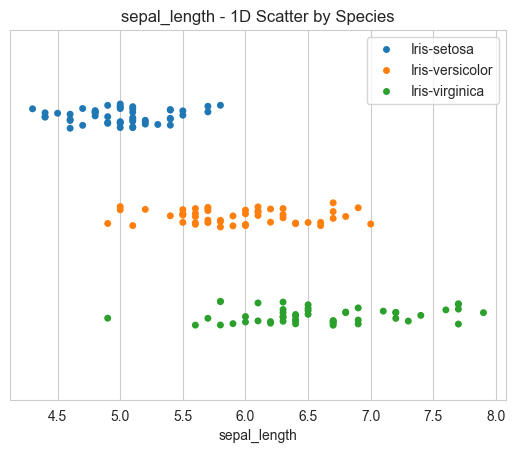

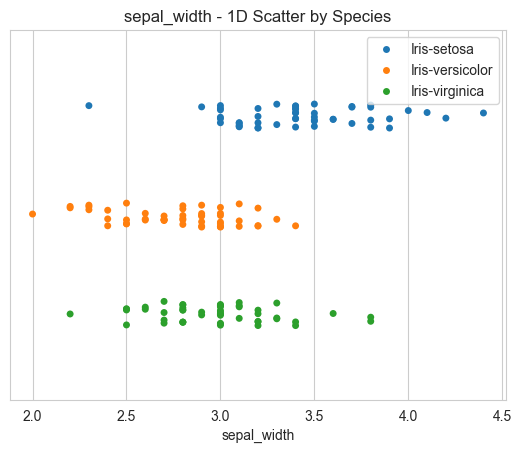

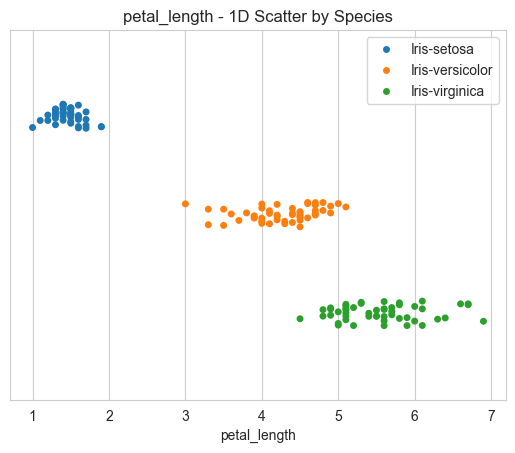

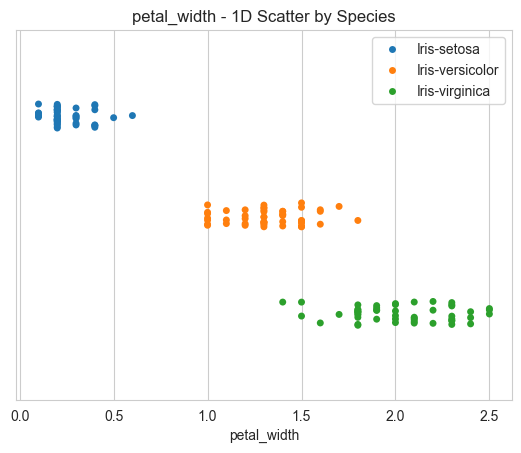

In [ ]:
# -----------------------
# 1-D SCATTER WITH SPECIES (BETTER)
# -----------------------
for col in features:
    plt.figure()
    sns.stripplot(data=iris, x=col, hue="species", dodge=True)
    plt.title(f"{col} - 1D Scatter by Species")
    plt.xlabel(col)
    plt.legend()
    plt.show()


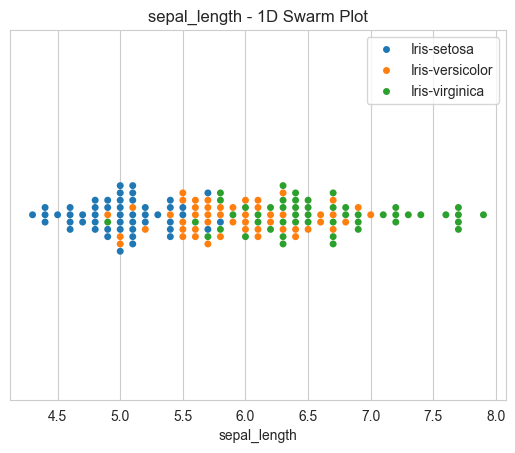

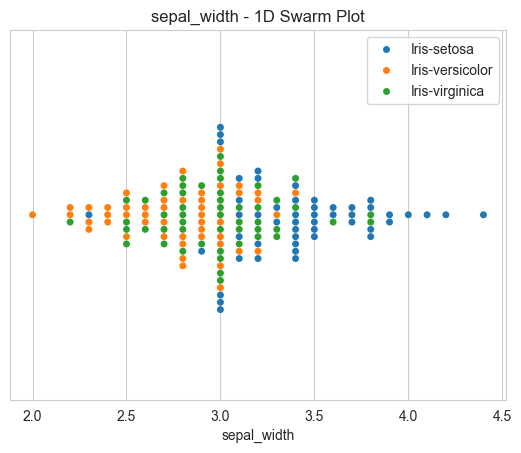

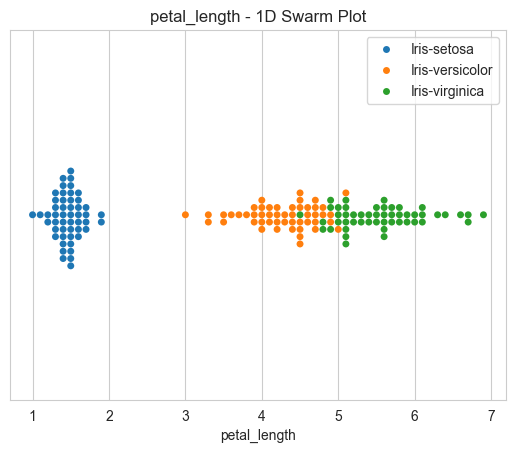

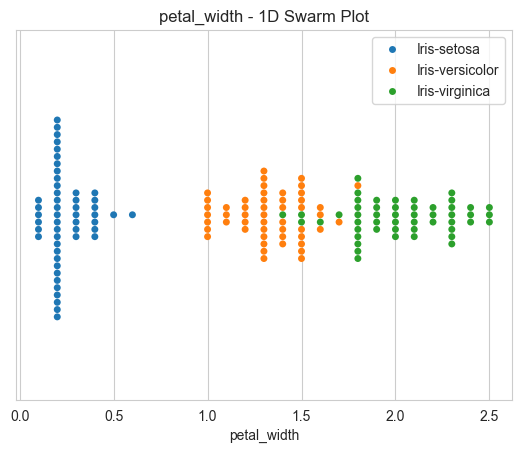

In [42]:
# -----------------------
# ALTERNATIVE: SWARM PLOT (no overlap)
# -----------------------
for col in features:
    plt.figure()
    sns.swarmplot(data=iris, x=col, hue="species")
    plt.title(f"{col} - 1D Swarm Plot")
    plt.xlabel(col)
    plt.legend()
    plt.show()

In [ ]:

# -----------------------
# HISTOGRAMS + PDF (KDE)
# -----------------------
for col in features:
    plt.figure()
    sns.histplot(iris[col], kde=True, stat="density", bins=20)
    plt.title(f"{col} - Histogram + PDF")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.show()

# Smoothening of histogram using kernel density estimation (KDE) gives us a better sense of the underlying distribution, especially with limited data.

In [ ]:
# -----------------------
# CDF (Empirical)
# -----------------------
for col in features:
    plt.figure()
    
    sorted_data = np.sort(iris[col])
    cdf = np.arange(1, len(sorted_data)+1) / len(sorted_data)
    
    plt.plot(sorted_data, cdf)
    plt.title(f"{col} - CDF")
    plt.xlabel(col)
    plt.ylabel("CDF")
    plt.show()

In [ ]:

# -----------------------
# SEPARATE BY SPECIES
# -----------------------
for col in features:
    plt.figure()
    sns.histplot(data=iris, x=col, hue="species", kde=True, stat="density", bins=20)
    plt.title(f"{col} - PDF by Species")
    plt.show()



In [ ]:
for col in features:
    plt.figure()
    for species in iris["species"].unique():
        data = np.sort(iris[iris["species"] == species][col])
        cdf = np.arange(1, len(data)+1) / len(data)
        plt.plot(data, cdf, label=species)
    
    plt.title(f"{col} - CDF by Species")
    plt.xlabel(col)
    plt.ylabel("CDF")
    plt.legend()
    plt.show()

# Mean, Variance and Std Deviation

In [50]:
iris_setosa = iris[iris["species"] == "Iris-setosa"]
iris_versicolor = iris[iris["species"] == "Iris-versicolor"]
iris_virginica = iris[iris["species"] == "Iris-virginica"]


In [ ]:
print("Mean:")
print(np.mean(iris_setosa["petal_length"], axis=0))
print(np.mean(iris_versicolor["petal_length"], axis=0))
print(np.mean(iris_virginica["petal_length"], axis=0))
print()
print()
print()

print("Standard Deviation:") # sqrt(variance)
print(np.std(iris_setosa["petal_length"]))
print(np.std(iris_versicolor["petal_length"]))
print(np.std(iris_virginica["petal_length"]))    

# Note:
# variance = np.mean((data - mean) ** 2) -> standard deviation = sqrt(variance)

Mean:
1.464
4.26
5.5520000000000005



Median:
1.5
4.35
5.55



Standard Deviation:
0.17176728442867112
0.4651881339845203
0.546347874526844


In [ ]:
# Mean get impacted by outliers, while median is more robust. 
# Standard deviation gives us a sense of variability, but can also be influenced by outliers. 
# Always good to look at both mean and median to understand the distribution better.

# Median, Percentile Quantile, IQR, MAD

In [ ]:
print("Median:")
print(np.median(iris_setosa["petal_length"]))
print(np.median(iris_versicolor["petal_length"]))
print(np.median(iris_virginica["petal_length"]))    
print()
print()
print()

print("Quantiles:")
print(np.percentile(iris_setosa["petal_length"], [25, 50, 75]))
print(np.percentile(iris_versicolor["petal_length"], [25, 50, 75]))
print(np.percentile(iris_virginica["petal_length"], [25, 50, 75]))
print()
print()
print()

print("90th Percentile:")
print(np.percentile(iris_setosa["petal_length"], 90))
print(np.percentile(iris_versicolor["petal_length"], 90))
print(np.percentile(iris_virginica["petal_length"], 90))
print()
print()
print()

from statsmodels import robust as mstats
print("Median Absolute Deviation:")
print(mstats.mad(iris_setosa["petal_length"]))
print(mstats.mad(iris_versicolor["petal_length"]))
print(mstats.mad(iris_virginica["petal_length"]))

# mad = median(|x_i - median(x)|) -> more robust measure of variability, 
# less influenced by outliers compared to standard deviation.

Median:
1.5
4.35
5.55



Quantiles:
[1.4   1.5   1.575]
[4.   4.35 4.6 ]
[5.1   5.55  5.875]



90th Percentile:
1.7
4.8
6.31



Median Absolute Deviation:
0.14826022185056031
0.5189107764769602
0.6671709983275211


In [ ]:
# Inter Quartile Range (IQR) = Q3 - Q1 -> another robust measure of variability, 
# focuses on the middle 50% of the data.

# Multivariate probability density, contour plot

/Users/jatinmishra/Desktop/Projects/ai-agents/BuildingModels/.venv/lib/python3.13/site-packages/seaborn/distributions.py:1128: UserWarning: cmap parameter ignored when using hue mapping.
  warnings.warn(msg, UserWarning)


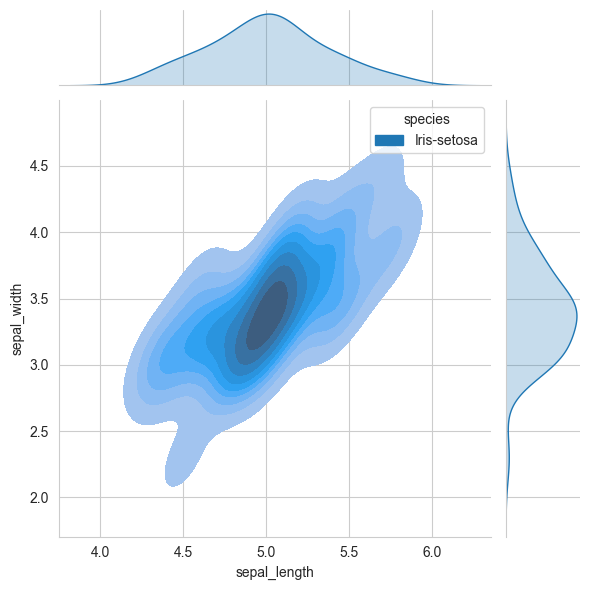

In [71]:
sns.jointplot(
    data=iris_setosa, 
    x="sepal_length", 
    y="sepal_width", 
    kind="kde", 
    fill=True, 
    cmap="mako", 
    hue="species"
    )
plt.show()